In [ ]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load data
wine = load_wine()
X = wine.data
y = wine.target

print(f"Dataset Shape: {X.shape}")

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Dataset Shape: (178, 13)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Find best odd K
k_values = [k for k in range(1, 21) if k % 2 != 0]
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    scores.append(knn.score(X_test_scaled, y_test))

best_k = k_values[np.argmax(scores)]

In [ ]:
# 2. Final Model and Detailed Metrics
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)
y_pred = final_model.predict(X_test_scaled)

In [ ]:
print(f"--- Model Evaluation (Best K: {best_k}) ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))


--- Model Evaluation (Best K: 13) ---
Accuracy Score: 0.9722

Confusion Matrix:
[[14  0  0]
 [ 1 13  0]
 [ 0  0  8]]

Classification Report:
              precision    recall  f1-score   support

     class_0       0.93      1.00      0.97        14
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



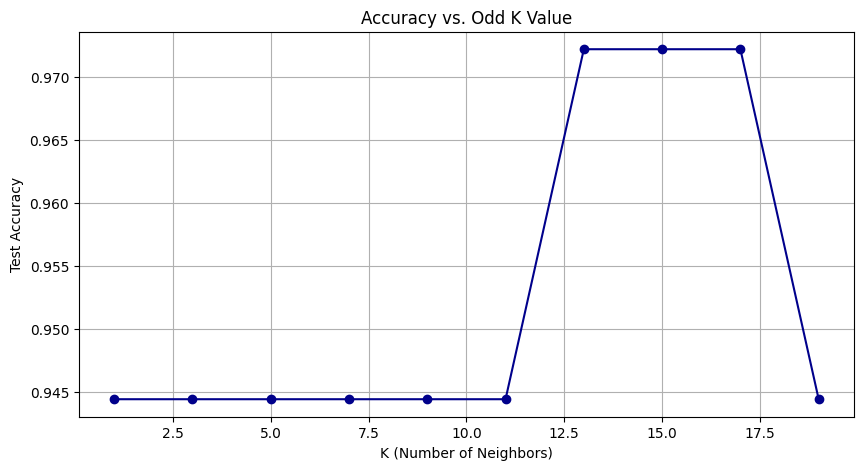

In [ ]:
#3. Visualization
plt.figure(figsize=(10, 5))
plt.plot(k_values, scores, marker='o', linestyle='-', color='darkblue')
plt.title('Accuracy vs. Odd K Value')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Test Accuracy')
plt.xticks#(k_values)
plt.grid(True)
plt.show()

In [ ]:
# Provide new data (Example: using sample index 20 from the dataset)
# Input must be a 2D array or reshaped to (1, -1)
new_input = X[20].reshape(1, -1)

# Scale the input using the existing scaler
new_input_scaled = scaler.transform(new_input)

# Predict
prediction = final_model.predict(new_input_scaled)
label = wine.target_names[prediction[0]]

print(f"Predicted Class: {prediction[0]} ({label})")

Predicted Class: 0 (class_0)
